In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np

### Load the dataset

In [2]:
raw_train_df = pd.read_csv(r"train.csv")
raw_train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
raw_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
raw_train_df.shape

(1460, 81)

In [5]:
# Function to get the columns in the raw dataframe
def get_cols():
  return raw_train_df.columns

In [6]:
get_cols()

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
# Drop id column as it is not necessary for model training
raw_train_df = raw_train_df.drop('Id', axis=1)
raw_train_df.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


### EDA

In [8]:
raw_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

Training dataset has 80 columns in total  
Contains 1460 rows of data

In [9]:
# Get small sets of numerical columns to analyze stats
train_df_num_cols = list(raw_train_df.select_dtypes(exclude='str').columns)
raw_train_df[train_df_num_cols[30:]].describe().T

# Total of 37 columns

,count,mean,std,min,25%,50%,75%,max
3SsnPorch,1460.0,3.409589,29.317331,0.0,0.0,0.0,0.0,508.0
ScreenPorch,1460.0,15.060959,55.757415,0.0,0.0,0.0,0.0,480.0
PoolArea,1460.0,2.758904,40.177307,0.0,0.0,0.0,0.0,738.0
MiscVal,1460.0,43.489041,496.123024,0.0,0.0,0.0,0.0,15500.0
MoSold,1460.0,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


Houses were sold between 2006 and 2010

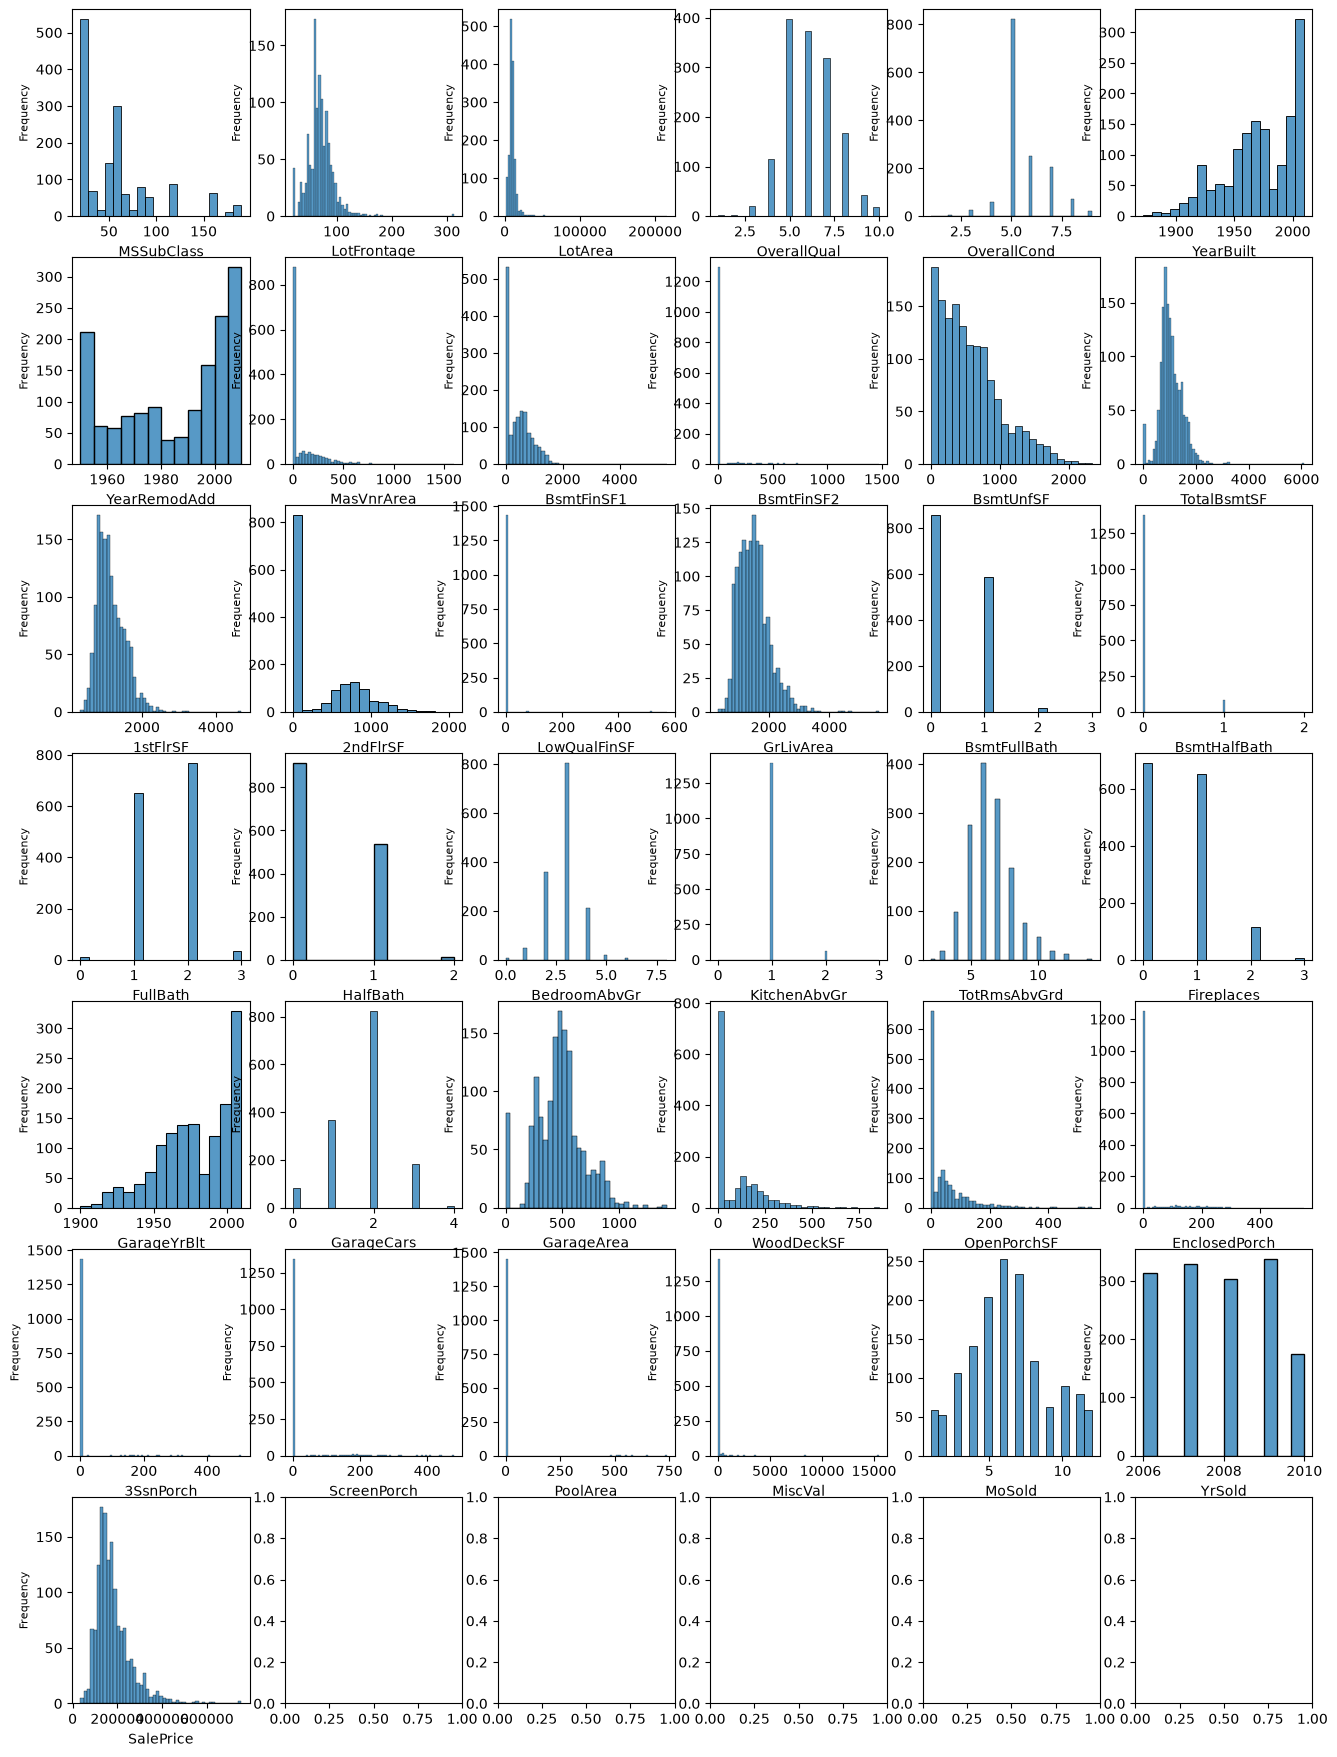

In [ ]:
# Distribution for all numerical columns
fig, axes = plt.subplots(nrows=7, ncols=6, figsize=(16, 22))

for ax, col in zip(axes.flat, train_df_num_cols):
  sns.histplot(data=raw_train_df, x=col, ax=ax)

  ax.set_ylabel('Frequency', fontsize=8)


House Price Distribution

<Axes: xlabel='SalePrice', ylabel='Count'>

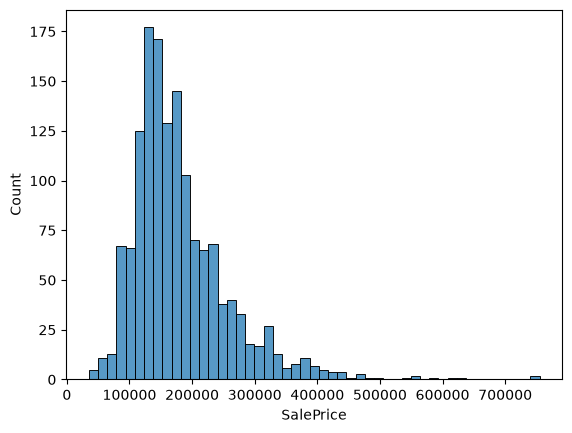

In [10]:
sns.histplot(raw_train_df, x='SalePrice')

As the house sale price increases the amount of houses sold decreases  
Most of the house prices recorded lie between 130k and 180k

In [11]:
# Features that are close to a positive correlation
sale_price_corr_df = raw_train_df.corrwith(raw_train_df['SalePrice'], numeric_only=True).sort_values(ascending=False).reset_index(name='corr')
sale_price_corr_df.head(10)

,index,corr
0,SalePrice,1.000000
1,OverallQual,0.790982
2,GrLivArea,0.708624
3,GarageCars,0.640409
4,GarageArea,0.623431
5,TotalBsmtSF,0.613581
6,1stFlrSF,0.605852
7,FullBath,0.560664
8,TotRmsAbvGrd,0.533723
9,YearBuilt,0.522897


The numerical values that display the highest correlation with SalePrice are:
- GrLivArea: 0.708624
- GarageCars: 0.640409
- GarageArea: 0.623431  

OverallQual has a correlation of 0.79 but it is more of a label that a numeric value

In [12]:
# Features that have a negative correlation to sale price
sale_price_corr_df.tail(10)

,index,corr
27,3SsnPorch,0.044584
28,BsmtFinSF2,-0.011378
29,BsmtHalfBath,-0.016844
30,MiscVal,-0.021190
31,LowQualFinSF,-0.025606
32,YrSold,-0.028923
33,OverallCond,-0.077856
34,MSSubClass,-0.084284
35,EnclosedPorch,-0.128578
36,KitchenAbvGr,-0.135907


In [13]:
sale_price_corr_df.set_index('index', inplace=True)

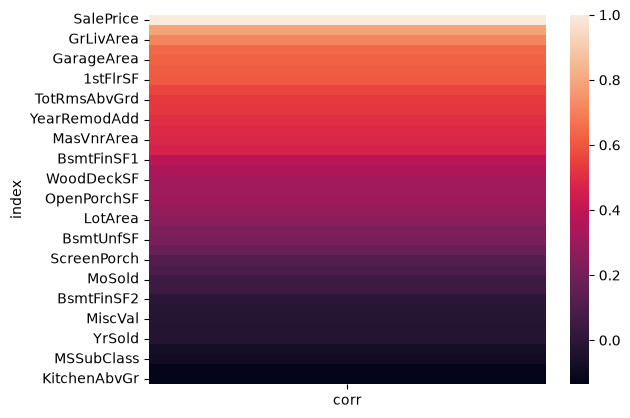

In [14]:
# Heatmap showing the relationship between sale price and other features
sns.heatmap(sale_price_corr_df)
plt.show()

<Axes: xlabel='SalePrice', ylabel='GrLivArea'>

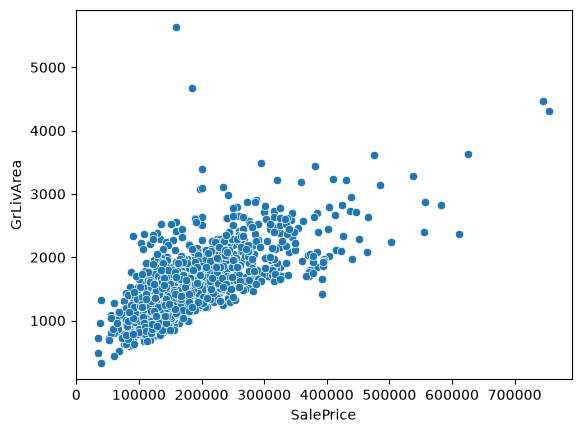

In [15]:
sns.scatterplot(raw_train_df, x='SalePrice', y='GrLivArea')

Above grade living area SF(GrLivArea) has a positive correlation with Sale Price

<Axes: xlabel='KitchenAbvGr', ylabel='SalePrice'>

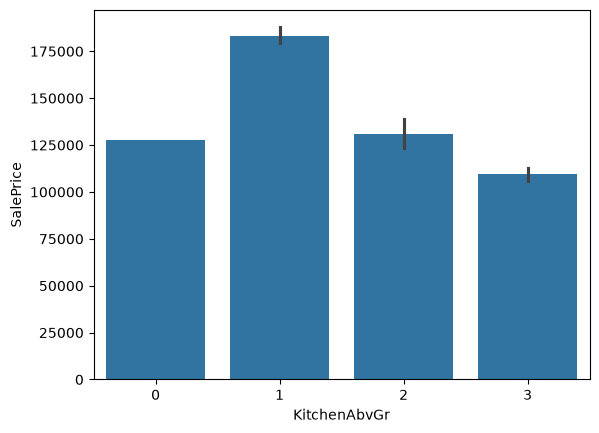

In [16]:
sns.barplot(raw_train_df, x='KitchenAbvGr', y='SalePrice')

Houses with 1 kitchen above grade have the highest prices

<Axes: xlabel='MSSubClass', ylabel='SalePrice'>

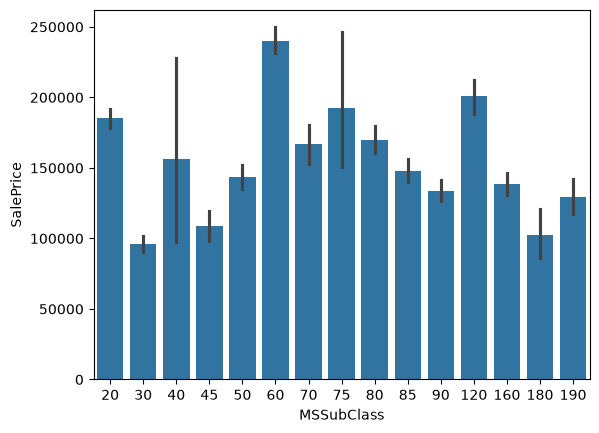

In [17]:
sns.barplot(raw_train_df, x='MSSubClass', y='SalePrice')

<Axes: xlabel='MSSubClass', ylabel='SalePrice'>

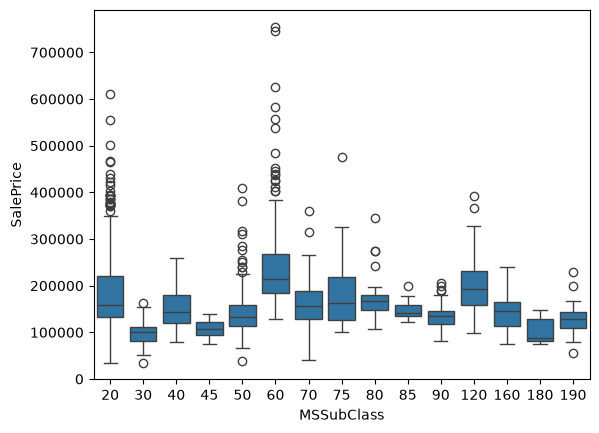

In [18]:
sns.boxplot(raw_train_df, x='MSSubClass', y='SalePrice')

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

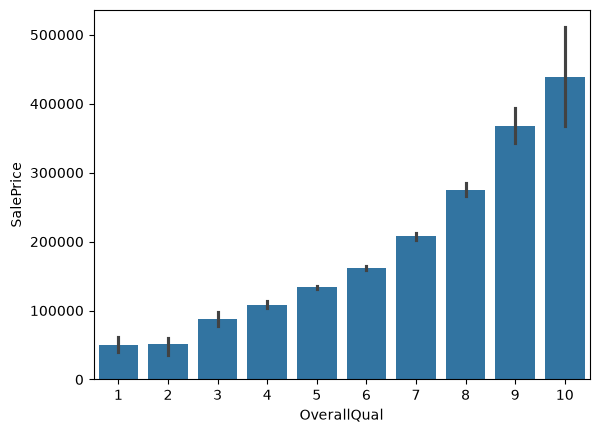

In [19]:
sns.barplot(raw_train_df, x='OverallQual', y='SalePrice')

As the overall quality of the house increases, so does the price

<Axes: xlabel='PoolQC', ylabel='SalePrice'>

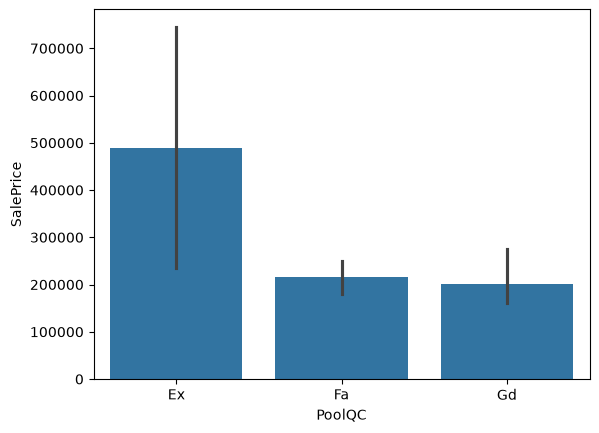

In [20]:
sns.barplot(raw_train_df, x='PoolQC', y='SalePrice')

As the pool quality decreases so does the price of the house

<Axes: xlabel='PoolArea', ylabel='SalePrice'>

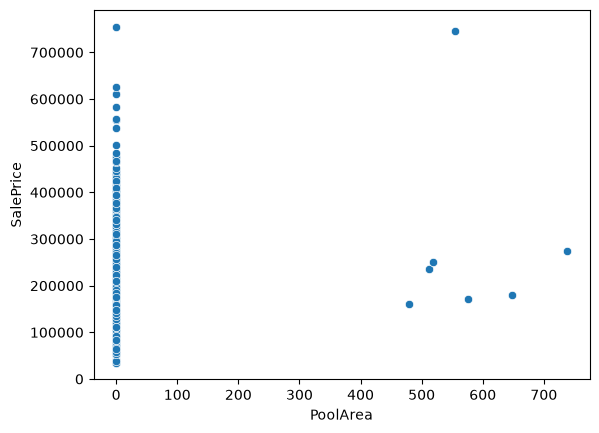

In [21]:
sns.scatterplot(raw_train_df, x='PoolArea', y='SalePrice')

Only 7 houses have a pool

In [22]:
# The feature/column to predict
target_col = 'SalePrice'

In [23]:
# Input columns
input_cols = get_cols().tolist()
input_cols.remove('SalePrice')

In [24]:
# Check all values in the target column are available
raw_train_df['SalePrice'].isna().sum()

np.int64(0)

### Preprocessing

#### Separate categorical and numerical columns

In [25]:
# Testing file
test_df = pd.read_csv(r'test.csv')
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [26]:
# Input and target columns for training the model
train_inputs = raw_train_df[input_cols].copy()
train_target = raw_train_df[target_col].copy()

In [27]:
train_target

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [28]:
# Input columns for testing the model
test_inputs = test_df[input_cols].copy()

In [29]:
print(raw_train_df.shape)
print(train_inputs.shape)
print(test_inputs.shape)

(1460, 80)
(1460, 79)
(1459, 79)


In [30]:
# Separate categorical and numerical columns
cat_cols = [
  'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
  'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
  'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
  'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
  'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
  'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
  'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
  'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
  'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'MSSubClass', 
  'OverallQual', 'OverallCond', 'MoSold'
]

num_cols = [
  'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 
  'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', 
  '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 
  'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 
  'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
  'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold'
]

#### Impute Null Values

In [31]:
get_cols()

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [32]:
len(cat_cols)

48

Two types of categorical features in the data:
- NA means the feature is not included in the house. 
- NA means that the feature is missing, not recorded.

In [33]:
# Categoriical columns where NA means that the feature is not included in the house
na_cat_col = ['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']
len(na_cat_col)

16

In [34]:
# Categorical columns where NA means that the value was not recorded
not_na_cat_col = [
  'MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'PavedDrive',
 'SaleType',
 'SaleCondition',
 'MSSubClass',
 'OverallQual',
 'OverallCond',
 'MoSold'
]
len(not_na_cat_col)

32

In [35]:
from sklearn.impute import SimpleImputer

In [36]:
train_inputs[cat_cols]

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,MSSubClass,OverallQual,OverallCond,MoSold
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,7,5,2
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Y,NaN,NaN,NaN,WD,Normal,20,6,8,5
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,7,5,9
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Y,NaN,NaN,NaN,WD,Abnorml,70,7,5,2
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,8,5,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,6,5,8
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Y,NaN,MnPrv,NaN,WD,Normal,20,6,6,2
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Y,NaN,GdPrv,Shed,WD,Normal,70,7,9,5
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Y,NaN,NaN,NaN,WD,Normal,20,5,6,4


Fill the categorical features that have NA indicating feature is not there with 'FNA' - Feature Not Available

In [37]:
na_cat_imputer = SimpleImputer(strategy='constant', fill_value='FNA').fit(train_inputs[na_cat_col])

In [38]:
train_inputs[na_cat_col] = na_cat_imputer.transform(train_inputs[na_cat_col])
test_inputs[na_cat_col] = na_cat_imputer.transform(test_inputs[na_cat_col])

Fill NA categorical columns, no value recorded with the most frequent value

In [39]:
not_na_cat_imputer = SimpleImputer(strategy='most_frequent').fit(train_inputs[not_na_cat_col])

In [40]:
train_inputs[not_na_cat_col] = not_na_cat_imputer.transform(train_inputs[not_na_cat_col])
test_inputs[not_na_cat_col] = not_na_cat_imputer.transform(test_inputs[not_na_cat_col])

In [41]:
# Imputting missing numeric values with the mean
num_imputer = SimpleImputer(strategy='mean').fit(train_inputs[num_cols])

In [42]:
train_inputs[num_cols] = num_imputer.transform(train_inputs[num_cols])
test_inputs[num_cols] = num_imputer.transform(test_inputs[num_cols])

#### Scaling numeric features

In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler().fit(train_inputs[num_cols])

In [45]:
# Scale the numerical columns in training, validation and test sets
train_inputs[num_cols] = scaler.transform(train_inputs[num_cols])
test_inputs[num_cols] = scaler.transform(test_inputs[num_cols])

In [46]:
train_inputs[num_cols]

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold
0,-0.229372,-0.207142,1.050994,0.878668,0.511418,0.575425,-0.288653,-0.944591,-0.459303,-0.793434,...,0.311725,0.351000,-0.752176,0.216503,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.138777
1,0.451936,-0.091886,0.156734,-0.429577,-0.574410,1.171992,-0.288653,-0.641228,0.466465,0.257140,...,0.311725,-0.060731,1.626195,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.614439
2,-0.093110,0.073480,0.984752,0.830215,0.323060,0.092907,-0.288653,-0.301643,-0.313369,-0.627826,...,0.311725,0.631726,-0.752176,-0.070361,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.138777
3,-0.456474,-0.096897,-1.863632,-0.720298,-0.574410,-0.499274,-0.288653,-0.061670,-0.687324,-0.521734,...,1.650307,0.790804,-0.752176,-0.176048,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.367655
4,0.633618,0.375148,0.951632,0.733308,1.364570,0.463568,-0.288653,-0.174865,0.199680,-0.045611,...,1.650307,1.698485,0.780197,0.563760,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.138777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.365633,-0.260560,0.918511,0.733308,-0.574410,-0.973018,-0.288653,0.873321,-0.238122,-0.542435,...,0.311725,-0.060731,-0.752176,-0.100558,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.614439
1456,0.679039,0.266407,0.222975,0.151865,0.084843,0.759659,0.722112,0.049262,1.104925,2.355701,...,0.311725,0.126420,2.033231,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,1.645210
1457,-0.183951,-0.147810,-1.002492,1.024029,-0.574410,-0.369871,-0.288653,0.701265,0.215641,0.065656,...,-1.026858,-1.033914,-0.752176,0.201405,-0.359325,-0.116339,-0.270208,-0.068692,4.953112,1.645210
1458,-0.093110,-0.080160,-0.704406,0.539493,-0.574410,-0.865548,6.092188,-1.284176,0.046905,-0.218982,...,-1.026858,-1.090059,2.168910,-0.704483,1.473789,-0.116339,-0.270208,-0.068692,-0.087688,1.645210


#### Encode categorical features

In [47]:
from sklearn.preprocessing import OneHotEncoder

In [48]:
raw_train_df[cat_cols]

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,MSSubClass,OverallQual,OverallCond,MoSold
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,7,5,2
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Y,NaN,NaN,NaN,WD,Normal,20,6,8,5
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,7,5,9
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Y,NaN,NaN,NaN,WD,Abnorml,70,7,5,2
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,8,5,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Y,NaN,NaN,NaN,WD,Normal,60,6,5,8
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Y,NaN,MnPrv,NaN,WD,Normal,20,6,6,2
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Y,NaN,GdPrv,Shed,WD,Normal,70,7,9,5
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Y,NaN,NaN,NaN,WD,Normal,20,5,6,4


In [49]:
train_inputs[cat_cols].dtypes

MSZoning            str
Street              str
Alley               str
LotShape            str
LandContour         str
Utilities           str
LotConfig           str
LandSlope           str
Neighborhood        str
Condition1          str
Condition2          str
BldgType            str
HouseStyle          str
RoofStyle           str
RoofMatl            str
Exterior1st         str
Exterior2nd         str
MasVnrType          str
ExterQual           str
ExterCond           str
Foundation          str
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Heating             str
HeatingQC           str
CentralAir          str
Electrical          str
KitchenQual         str
Functional          str
FireplaceQu         str
GarageType          str
GarageYrBlt      object
GarageFinish        str
GarageQual          str
GarageCond          str
PavedDrive          str
PoolQC              str
Fence               str
MiscFeature     

In [50]:
train_inputs[cat_cols].select_dtypes(exclude='str').columns.tolist()

['GarageYrBlt', 'MSSubClass', 'OverallQual', 'OverallCond', 'MoSold']

In [51]:
# Convert all categorical columns to strings for encoding
train_inputs[cat_cols] = train_inputs[cat_cols].astype(str)
test_inputs[cat_cols] = test_inputs[cat_cols].astype(str)

In [52]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[cat_cols])

In [53]:
encoded_cols = list(encoder.get_feature_names_out(cat_cols))
encoded_cols

['MSZoning_C (all)',
 'MSZoning_FV',
 'MSZoning_RH',
 'MSZoning_RL',
 'MSZoning_RM',
 'Street_Grvl',
 'Street_Pave',
 'Alley_FNA',
 'Alley_Grvl',
 'Alley_Pave',
 'LotShape_IR1',
 'LotShape_IR2',
 'LotShape_IR3',
 'LotShape_Reg',
 'LandContour_Bnk',
 'LandContour_HLS',
 'LandContour_Low',
 'LandContour_Lvl',
 'Utilities_AllPub',
 'Utilities_NoSeWa',
 'LotConfig_Corner',
 'LotConfig_CulDSac',
 'LotConfig_FR2',
 'LotConfig_FR3',
 'LotConfig_Inside',
 'LandSlope_Gtl',
 'LandSlope_Mod',
 'LandSlope_Sev',
 'Neighborhood_Blmngtn',
 'Neighborhood_Blueste',
 'Neighborhood_BrDale',
 'Neighborhood_BrkSide',
 'Neighborhood_ClearCr',
 'Neighborhood_CollgCr',
 'Neighborhood_Crawfor',
 'Neighborhood_Edwards',
 'Neighborhood_Gilbert',
 'Neighborhood_IDOTRR',
 'Neighborhood_MeadowV',
 'Neighborhood_Mitchel',
 'Neighborhood_NAmes',
 'Neighborhood_NPkVill',
 'Neighborhood_NWAmes',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'Neighborhood_OldTown',
 'Neighborhood_SWISU',
 'Neighborhood_Sawyer',
 'N

In [54]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[cat_cols])

C:\Users\mugun\AppData\Local\Temp\ipykernel_3740\2713693534.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[cat_cols])


In [55]:
test_inputs[encoded_cols] = encoder.transform(test_inputs[cat_cols])

C:\Users\mugun\AppData\Local\Temp\ipykernel_3740\1707001774.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_inputs[encoded_cols] = encoder.transform(test_inputs[cat_cols])


In [56]:
# Combine the processed numerical data
X_train = train_inputs[num_cols + encoded_cols]
X_test = test_inputs[num_cols + encoded_cols]

In [57]:
X_train.head()

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9
0,-0.229372,-0.207142,1.050994,0.878668,0.511418,0.575425,-0.288653,-0.944591,-0.459303,-0.793434,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.451936,-0.091886,0.156734,-0.429577,-0.574410,1.171992,-0.288653,-0.641228,0.466465,0.257140,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.093110,0.073480,0.984752,0.830215,0.323060,0.092907,-0.288653,-0.301643,-0.313369,-0.627826,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.456474,-0.096897,-1.863632,-0.720298,-0.574410,-0.499274,-0.288653,-0.061670,-0.687324,-0.521734,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.633618,0.375148,0.951632,0.733308,1.364570,0.463568,-0.288653,-0.174865,0.199680,-0.045611,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
train_target

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [59]:
X_test

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9
0,0.451936,0.110763,-0.340077,-1.156380,-0.574410,0.053428,0.604293,-0.672923,-0.400017,-0.689929,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.497357,0.375850,-0.439440,-1.301740,0.023903,1.051363,-0.288653,-0.365032,0.619239,0.430511,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.179413,0.332053,0.852269,0.636400,-0.574410,0.761852,-0.288653,-0.974021,-0.295127,-0.607125,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.361095,-0.054002,0.885390,0.636400,-0.463612,0.347326,-0.288653,-0.550672,-0.299687,-0.612300,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.228623,-0.552407,0.686666,0.345679,-0.574410,-0.396190,-0.288653,1.018211,0.507509,0.303718,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,-2.227875,-0.859988,-0.041991,-0.720298,-0.574410,-0.973018,-0.288653,-0.048086,-1.166169,-1.595596,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1455,-2.227875,-0.864197,-0.041991,-0.720298,-0.574410,-0.420316,-0.288653,-0.618589,-1.166169,-1.595596,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1456,4.085578,0.950423,-0.373198,0.539493,-0.574410,1.711535,-0.288653,-1.284176,0.379817,0.158811,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1457,-0.365633,-0.007600,0.686666,0.345679,-0.574410,-0.233889,-0.288653,0.017567,-0.331610,-0.498445,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Save training and testing inputs and target to a csv file

In [60]:
X_train.to_csv(r'processed_data\X_train.csv', index=False)
X_test.to_csv(r'processed_data\X_test.csv', index=False)

In [61]:
train_target.to_csv(r'processed_data\y_train.csv', index=False)